# Coursework Set Week 6

**Common remarks**:

* Deadline: Sunday at 23:59h for the week of this task
* <font color='red'>Keep all the information in this template unaltered!</font>

**Please fill in the following fields:**

* Name: Diya Chatani
* Username: dchatani
* Student number: S5882273
* Group (AS1, etc.): AS2

-----

In [ ]:
totalpoints = currentpoints = 0

### Exploring a HI data cube (7 pt) <font color='red'><b>COURSEWORK</b></font>
   
* Download FITS image [ngc6946.fits](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/ngc6946.fits)
* Create a mosaic with 5 rows and 10 columns of channel maps for the Z indices ``range(1, 101, 2)``
* Remove axis labeling with Axes methods ``set_xticklabels([])`` and ``set_yticklabels([])``.
* If you add two channel maps you get a new map where each pixel is the sum of the two maps. If you add all channel maps (not the noisy ones), you get a so called *total HI* map.

    * Select a suitable range of channel maps and sum them to get a total HI map. Make a plot of this map
    * Label the axes with the header values of ``CTYPE1`` and ``CTYPE2``.
    * Make a locatable colorbar and label its Y axis with the header value of ``BUNIT``. 
        
* A *position velocity* (PV) map is a slice through the data at one fixed spatial position. 
   It tells you something about how the velocities in a galaxy behave as function of position 
   and one fixed position.   
   In NumPy jargon a PV map can be an YZ slice or a XZ slice. 

    * Plot a PV map for a fixed Right Ascension (R.A.) with index 50.
    * Plot a vertical line at Dec. with index 40.
    * Label the axes with the header values of ``CTYPE2`` and ``CTYPE3``. <br>&nbsp;</br>
        
* A *global HI spectral profile* is a slice in along the spectral axis at a fixed Right Ascension and Declination.
   It is a 1D curve with intensities as function of frequency (or velocity). It shows you at which 
   velocity most of the gas is rotating in a galaxy given a position in R.A. and Dec.

    * Plot a global profile at R.A. with index 50 and Dec. with index 40.
    * Label the plot axes with the header values of ``CTYPE3`` and ``BUNIT``. <br>&nbsp;</br>

* What is the relation between this profile and the vertical line in the previous plot of the PV diagram?   

**Answers**:

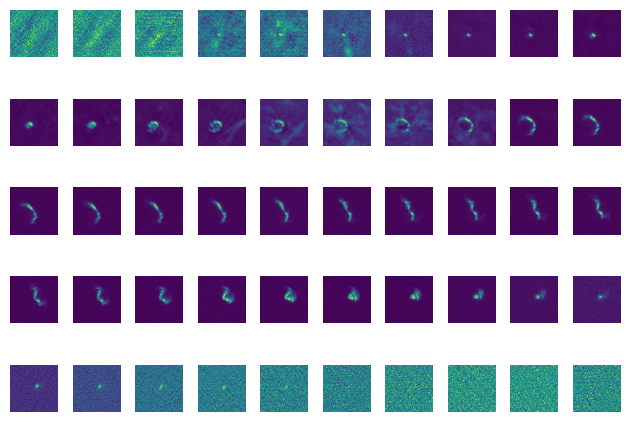

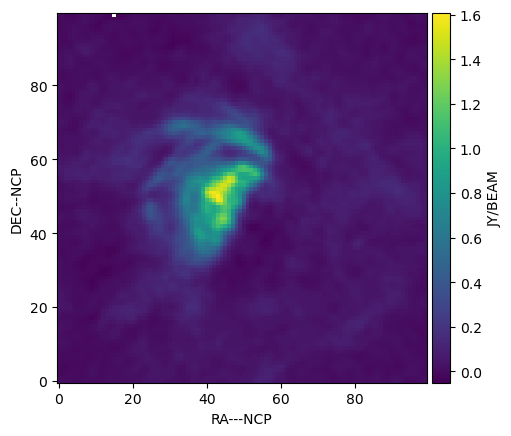

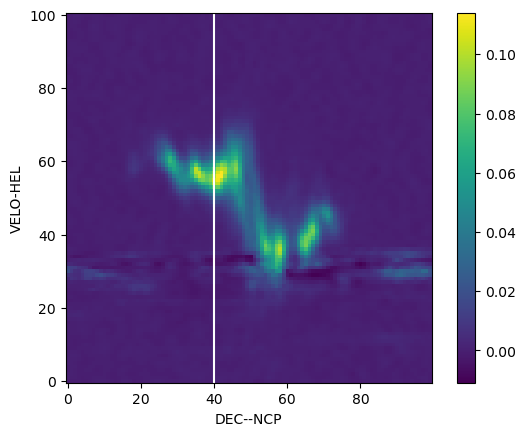

In [1]:
import numpy as np
from astropy.io import fits
from scipy.stats import mode
from matplotlib.pyplot import figure, show
from matplotlib.pyplot import subplots, tight_layout
from mpl_toolkits.axes_grid1 import make_axes_locatable

hdulist = fits.open("ngc6946.fits")
data = hdulist[0].data
header = hdulist[0].header

fig, axes = subplots(5,10)
z_vals= range(1,101,2)
for axis, z in zip(axes.flatten(),z_vals): #zipping assigns each axis to an index 
    axis.imshow(data[z,:,:])  
    axis.set_xticklabels([]) 
    axis.set_yticklabels([])
    axis.axis("off")
fig.tight_layout()


channelmaps = data[5:50, : , :]
HI = np.sum(channelmaps,axis=0) #sums over z axis
fig, axes = subplots()
total_map = axes.imshow(HI,origin="lower")
axes.set_xlabel(header["CTYPE1"])
axes.set_ylabel(header["CTYPE2"])

divider = make_axes_locatable(axes)
cax = divider.append_axes("right", size = "5%", pad = 0.05)
colorbar = fig.colorbar(total_map,cax=cax)
colorbar.set_label(header["BUNIT"])

#Plot a PV map for a fixed Right Ascension (R.A.) with index 50.
## in YZ plane: 

pvslice = data[ : , : ,50] #all z values, y values, in x index 50
fig, axes = subplots()
pv_map = axes.imshow(pvslice, origin = "lower")
colorbar = fig.colorbar(pv_map,ax=axes)

#Plot a vertical line at Dec. with index 40.
#Label the axes with the header values of CTYPE2 and CTYPE3.
axes.axvline(40,color = "w", label = "incl = 40")
axes.set_xlabel(header["CTYPE2"])
axes.set_ylabel(header["CTYPE3"])


show()


The relation between the line and the profile is that the line indicates that the declination is 40 degrees in the plane of VELO-HEL and RA--NCP

In [ ]:
# Leave unaltered
totalpoints += 7
currentpoints += 0.0

### Galaxy Colour (5 pt) <font color='red'><b>COURSEWORK</b></font>
   
Download [SDSS_DR17_galaxies.fits](https://brightspace.rug.nl/content/enforced/457626-WBAS018-05.2025-2026.1/SDSS_DR17_galaxies.fits), which contains apparent magnitude in ``u, g, r, i, z`` five SDSS broad-band filters.

* Create a Pandas DataFrame from the FITS table.
* Filter out any data with negative values.
* Calculate every combination of colours from each broad band filter, e.g. u-g, u-r, u-i, u-z, g-r, ......
* Calculate the mean and standard deviation of the each colour.
* Use Object-Oriented Plotting to create a corner plot using derived colours.
* Set the xlim and ylim to be within three standard deviation.
* Add title for each histogram with information of the mean and standard deviation of each colour in the format of $\mu\pm\sigma$
 (to one decimal place).

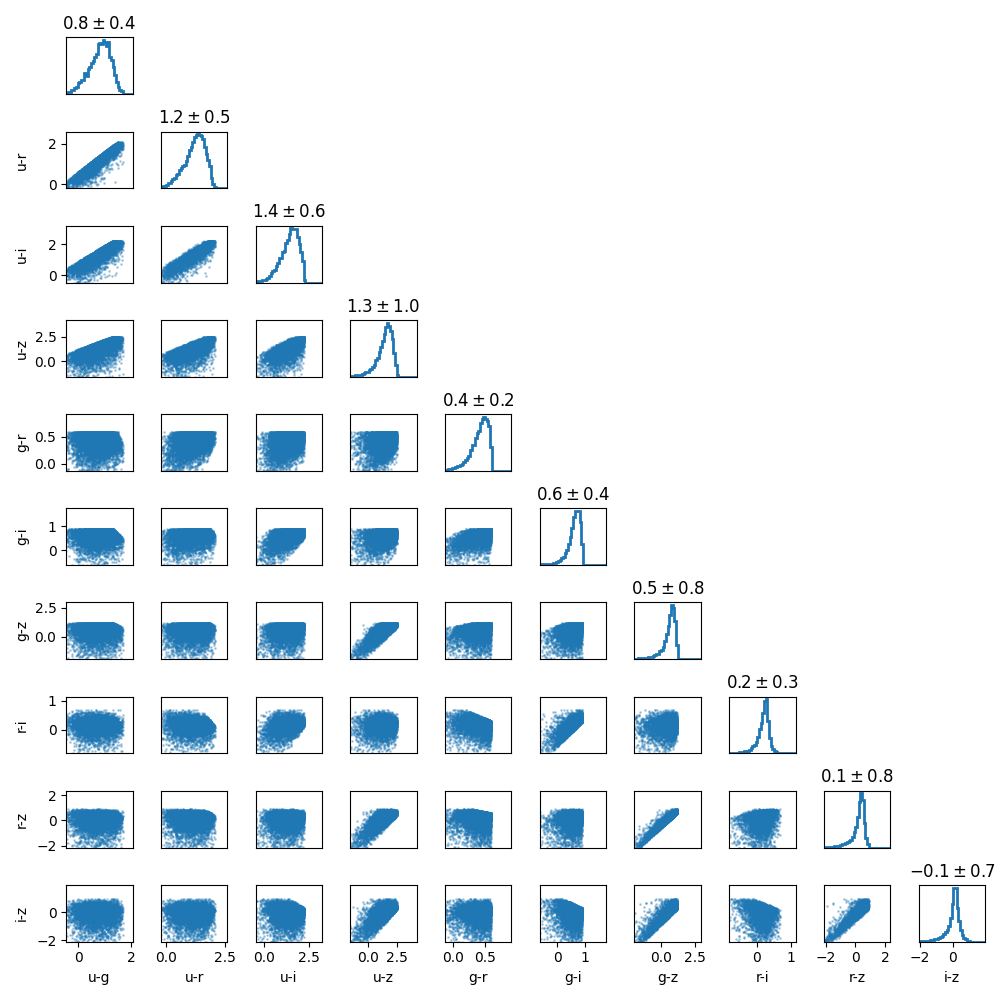
   
**Plot and answer**:

10.0


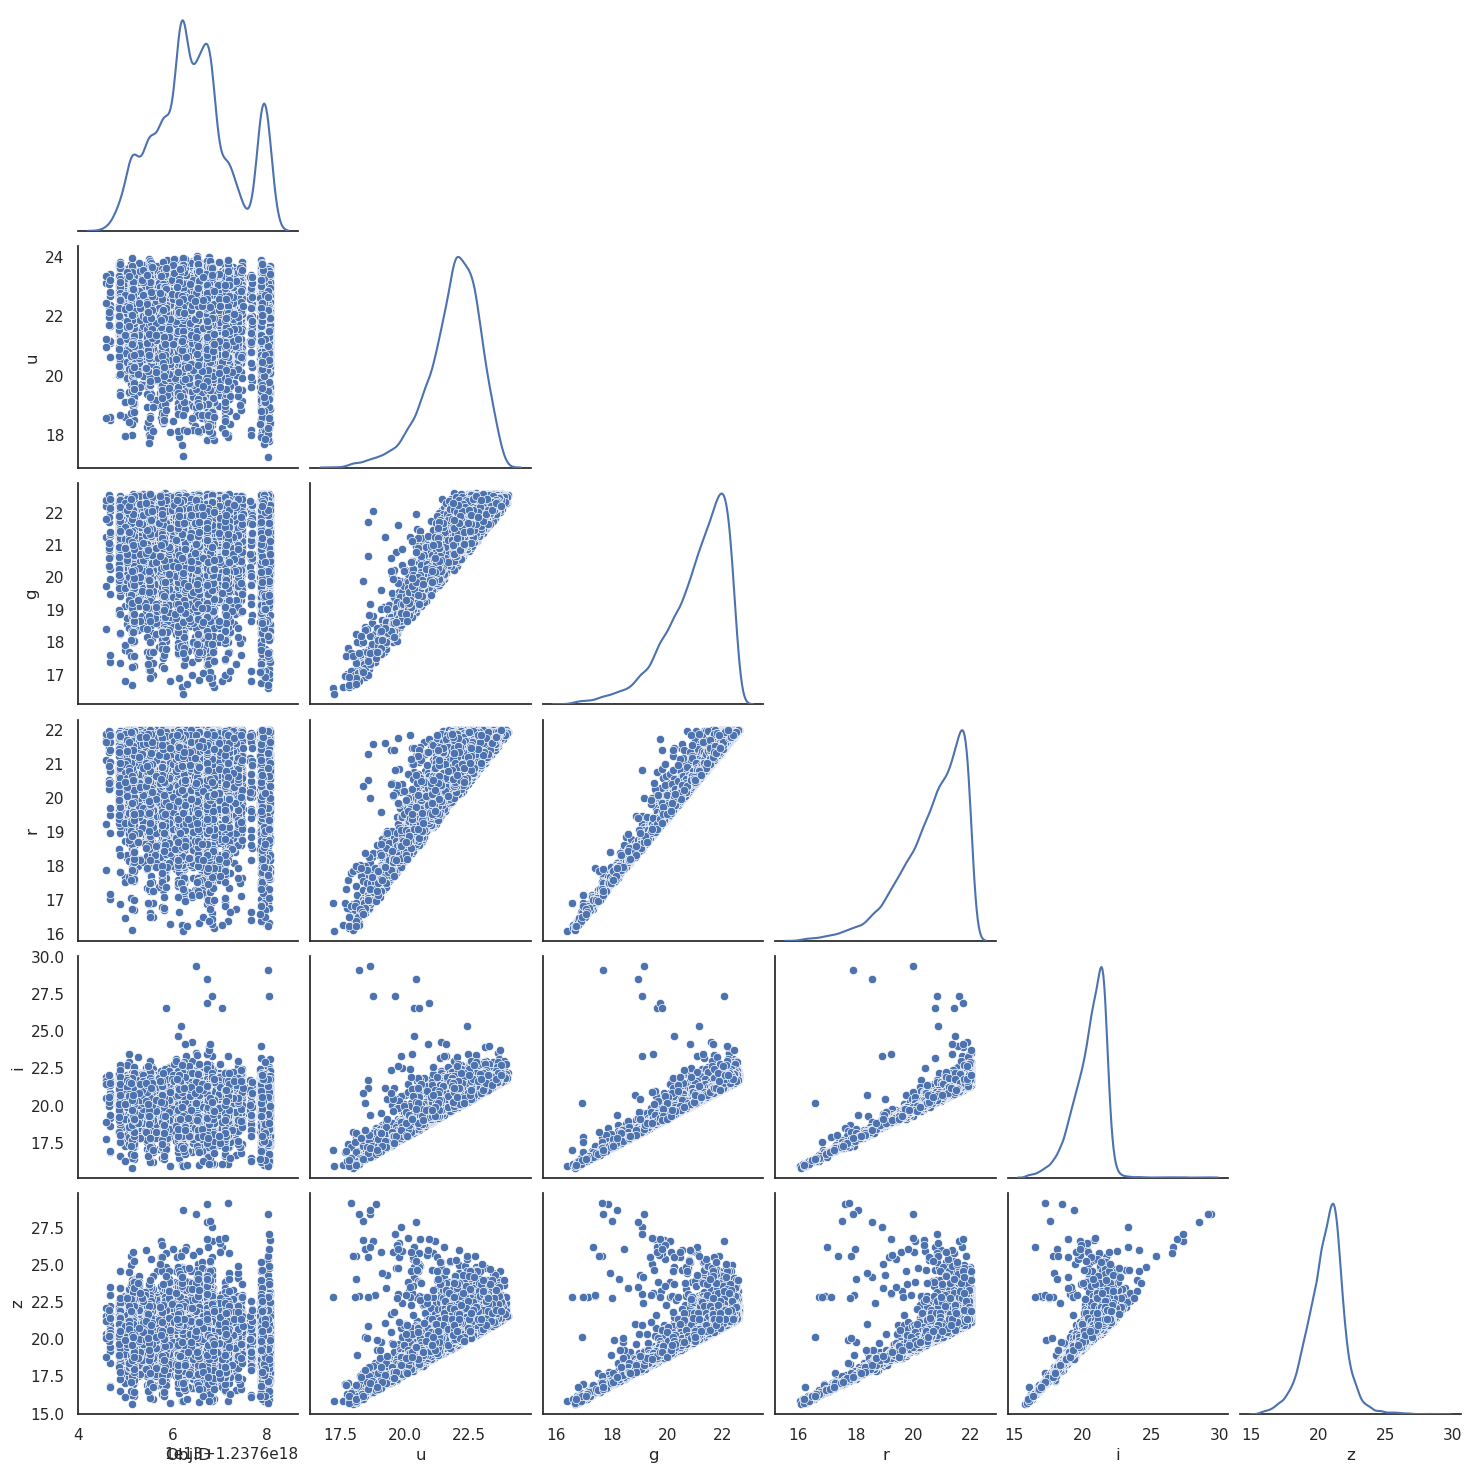

In [40]:

import pandas as pd
from astropy.table import Table
from astropy.io import fits
import scipy.special as special
import numpy as np
import seaborn
import matplotlib.pyplot as plt

data =Table.read("SDSS_DR17_galaxies.fits",format="fits") #found this method on stack exchange; works because Table has a to_pandas() function
dataframe = data.to_pandas()
filtered = dataframe[dataframe>=0].dropna() #replaces numbers less than 0 with NONE and then dropna() removes those rows with none
colors = ["u", "g", "r", "i", "z"]
combinations = special.comb(len(colors),2) #five filters, two in each combination
print(combinations)

for i, col in enumerate(colors): 
    mean = np.mean(filtered[col].to_numpy())
    std = np.std(filtered[col].to_numpy())
    ax = graph.axes[i,i]
    ax.set_xlim(-3*std,3*std)
    ax.set_ylim(-3*std,3*std)
    ax.set_title(f"{mean:1f} $ \pm $ {std:1f}")


#Use Object-Oriented Plotting to create a corner plot using derived colours.
seaborn.set(style="white")
graph = seaborn.pairplot(filtered,corner = True,diag_kind="kde",diag_kws=dict(fill=False))

plt.show()

# for some reason the titles aren't showing

In [ ]:
# Leave unaltered
totalpoints += 5
currentpoints += 0.0

### Astroquery: retrieving SDSS image and spectra (5 pt) <font color='red'><b>COURSEWORK</b></font>

Spiral galaxy M77 (NGC 1068) is a bright galaxy known for hosting an active galactic nucleus (AGN). With Astropy package, we construct M77's coordinate using the code below.

```python
from astropy import coordinates as coords

# Coordinates of M77
ra = 40.6696  # degrees
dec = -0.0133  # degrees
pos = coords.SkyCoord(ra, dec, unit="deg", frame="icrs")
```

* Use ``astroquery`` ([search regions](https://astroquery.readthedocs.io/en/latest/sdss/sdss.html#searching-regions-and-multiple-objects)) on the ``pos``, containing RA and DEC of this galaxy, to retrieve its SDSS spectrum using ``get_spectra()``. The search radius sets as ``10 arcsec`` for searching.
* The return object of ``get_spectra()`` is a list of [HDUList](https://docs.astropy.org/en/stable/io/fits/api/hdulists.html#astropy.io.fits.HDUList) objects.
* Retrieve flux and wavelengths using columns ``flux`` and ``loglam``. Note that the wavelength is in logarithmic value, you need to convert it back to a linear scale.
* The redshift of M77 is approximately ``z~0.0038``. Calculating the rest-frame wavelengths.
* Use Object-Oriented Plotting to plot:
    * a rest-frame spectrum which corrects the redshift effect (top)
    * a zoom-in spectrum at wavelength between 6450 and 6650 angstrom (bottom)
* Draw vertical lines for H$\alpha$ lines in both frames. Label them and show with legend.
* Draw vertical lines indicating approximately where the peak of the flux is, which in fact should be the H$\alpha$ line.
* An example plot is shown below.
* Calculating the velocity indicated by the difference between the two wavelengths.
* Share your thought using a markdown on what might be causing this offset. This question will not be graded, and meant to train a bit your scientific thinking. Feel free to express any thought.

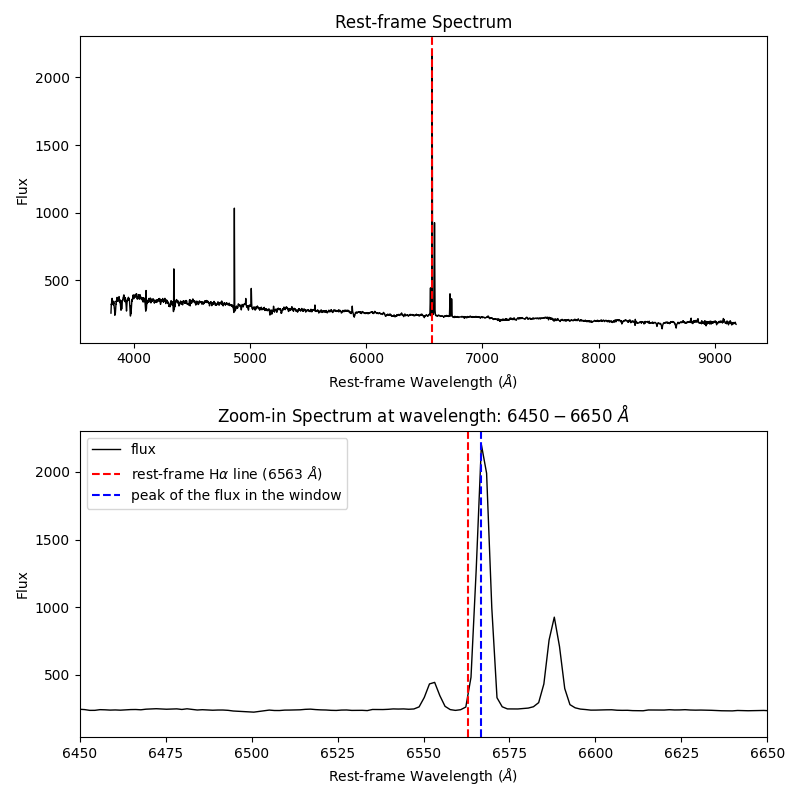

In [5]:
!pip install astroquery

Defaulting to user installation because normal site-packages is not writeable


In [1]:
from astropy import coordinates as coords
from astroquery.sdss import SDSS
import astropy.units as u
from scipy import constants as constants
import numpy as np
import matplotlib.pyplot as plt

# Coordinates of M77
ra = 40.6696  # degrees
dec = -0.0133  # degrees
pos = coords.SkyCoord(ra, dec, unit="deg", frame="icrs")

xid = SDSS.query_region(pos, radius='10 arcsec', spectro=True)
sp = SDSS.get_spectra(matches=xid)

flux = sp["flux"].data
loglength = sp["loglam"].data
wavelength = np.logspace(loglength,base=10)
z = 0.0038
rest = wavelength/(z+1)

fig, (ax1,ax2) = plt.subplots(2,1)
ax1.plot(rest, flux)
ax1.set_xlabel("Rest-frame Wavelength ($\mathring{A}$)")
ax1.set_ylabel("Flux")
ax1.axvline(H,label="H line")
ax1.axvline(np.max(flux),label="max")
ax1.set_title("Rest=Frame spectrum")
# for the wavelength between 6450 and 6650 i can use a mask:
mask = (rest>=6450) & (rest <=6650)
rest_toplot,flux_toplot = rest[mask], flux[mask]
ax2.plot(rest_toplot,flux_toplot)
ax2.set_xlabel("Rest-frame Wavelength ($\mathring{A}$)")
ax2.set_ylabel("Flux")
ax2.axvline(H,label="H line")
ax2.axvline(np.max(flux),label="max")
ax2.set_title("Zoom in spectrum at wavelength 6450 - 6650 $\mathring{A}$")


plt.show()

#Draw vertical lines for H
# lines in both frames. Label them and show with legend.
#Draw vertical lines indicating approximately where the peak of the flux is, which in fact should be the H
# line.
#An example plot is shown below.
#Calculating the velocity indicated by the difference between the two wavelengths.
#Share your thought using a markdown on what might be causing this offset. This question will not be graded, and meant to train a bit your scientific thinking. Feel free to express any thought.

KeyboardInterrupt: 

Answer: factors that may be influencing this offset include: occlusion due to dust particles, redshift because of the movement of the object.


(i'm not sure how the graph turned out because the query timed out for me)

In [ ]:
# Leave unaltered
totalpoints += 5
currentpoints += 0.0

### Comparing an image in different color scales (stretches) (4pt) <font color='red'><b>COURSEWORK</b></font>

Given is the Blaauw observatory FITS file
[20210422_Li_.00000066.FIT](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/20210422_Li_.00000066.FIT)

Use the `imdisplay()` function from the notebook *The art of plotting an image* to make a mosaic with this image using all the different scales (stretches) available to that function. 

* Add a proper docstring to the function.
* Show the used scale in the title of the plot. (hints: tight_layout, fontsize).
* Also include the image without scaling as the first plot in the mosaic.

**Answer**:

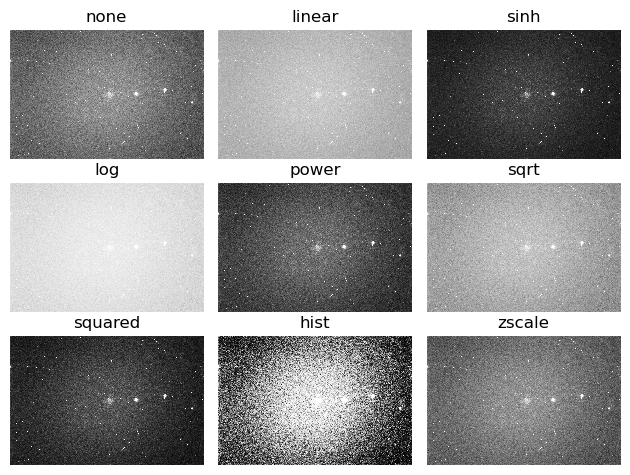

In [3]:
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure, show
from matplotlib.pyplot import subplots, show
from astropy.visualization import ImageNormalize
from astropy.visualization import SinhStretch, AsymmetricPercentileInterval, LinearStretch,\
                                  LogStretch, PowerStretch, SqrtStretch, SquaredStretch,\
                                  HistEqStretch, ZScaleInterval



data = fits.open("20210422_Li_.00000066.FIT")
image_data = data[0].data
def imdisplay(data,
              ax,
              vmin=None, vmax=None,
              percentlow=1, percenthigh=99,
              zscale=False,
              scale='linear',
              power=1.5,
              cmap='gray',
              **kwargs):
    if zscale:
        # Always overwrite vmin and vmax
        interval = ZScaleInterval()
        vmin, vmax = interval.get_limits(data)
    if vmin is None or vmax is None:
        interval = AsymmetricPercentileInterval(percentlow, percenthigh)
        vmin2, vmax2 = interval.get_limits(data)
        if vmin is None:
            vmin = vmin2
        if vmax is None:
            vmax = vmax2

    if scale == 'linear':
        stretch = LinearStretch(slope=0.5, intercept=0.5)
    elif scale == 'sinh':
        stretch = SinhStretch()
    elif scale == 'log':
        stretch = LogStretch()
    elif scale == 'power':
        stretch = PowerStretch(power)
    elif scale == 'sqrt':
        stretch = SqrtStretch()
    elif scale == 'squared':
        stretch = SquaredStretch()
    elif scale == 'hist':
        stretch = HistEqStretch(data)  # Needs argument data and data min, max for vmin, vmax
        vmin = data.min(); vmax = data.max()
    elif scale == 'zscale':
        stretch = LinearStretch()
    else:
        stretch = LinearStretch()
    norm = ImageNormalize(vmin=vmin, vmax=vmax, stretch=stretch)
    return ax.imshow(data, interpolation='none', origin='lower', norm=norm, cmap=cmap, **kwargs)
scales = ["none", "linear", "sinh", "log", "power", "sqrt", "squared", "hist", "zscale"]

fig, axes = subplots(3,3)
axes = axes.flatten()
for i, scale in enumerate(scales):
    ax = axes[i]
    imdisplay(image_data, ax, zscale=True,scale=scale)
    ax.set_title(scale)
    ax.axis("off")

plt.tight_layout()
show()


In [5]:
# Leave unaltered
totalpoints += 4
currentpoints += 0.0

NameError: name 'totalpoints' is not defined

In [5]:
!pip install astrolign

Defaulting to user installation because normal site-packages is not writeable
ERROR: Could not find a version that satisfies the requirement astrolign (from versions: none)
ERROR: No matching distribution found for astrolign


### Image stacking optical data (6pt) <font color='red'><b>COURSEWORK</b></font>

Select one of the suitable observations from the next table or
find one yourself in the
[Blaauw Observatory Overview](https://www.astro.rug.nl/intranet/sterrenwacht/files.py)

* Following the stacking procedure in the notebook about image stacking for the data you selected. Show the result.
* Align the images and repeat the stacking procedure. Show the result.
* Remove all unnecessary code and markdown text.
* Include code and result in your report.

| nr | Folder on data server |
| :---  | :---: |
| 2  | ``/net/dataserver3/data/users/sterrenwacht/images/210418/STL-6303E/i/`` |
| 3  | ``/net/dataserver3/data/users/sterrenwacht/images/190515/STL-6303E/i/`` |
| 4  | ``/net/dataserver3/data/users/sterrenwacht/images/190428/STL-6303E/i/`` |
| 5  | ``/net/dataserver3/data/users/sterrenwacht/images/190419/STL-6303E/i/`` |
| 6  | ``/net/dataserver3/data/users/sterrenwacht/images/180504/STL-6303E/i/`` |
| 7  | ``/net/dataserver3/data/users/sterrenwacht/images/160913/STL-6303E/i/`` |
| 8  | ``/net/dataserver3/data/users/sterrenwacht/images/140912/STL-6303E/i/`` |
| 9  | ``/net/dataserver3/data/users/sterrenwacht/images/131001/STL-6303E/i/`` |
| 10 | ``/net/dataserver3/data/users/sterrenwacht/images/101212/STL-6303E/i/`` |

**Code and plot**:

Shape of data cube with stacked images: (73, 2048, 3072)


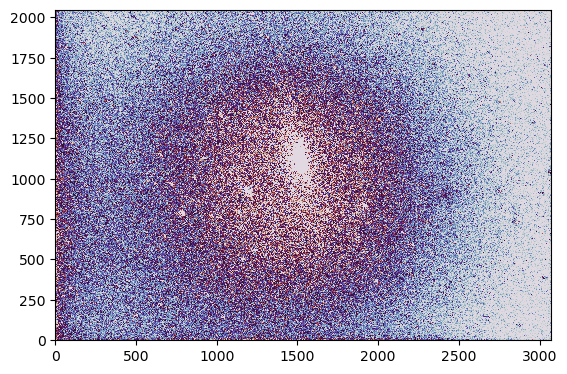

In [8]:
from pathlib import Path
from matplotlib.pyplot import subplots, show


datadir = "/Users/users/dchatani/PROGNUM-repo/Task6/DATA2"  # Replace by your own data folder (not in home!)
excludes = ['BIAS', 'FLAT', 'DARK']  # Exclude these images if these are opart of the file name

path = Path(datadir)
filepaths = []
images = []

for filepath in path.iterdir():
    hdulist = fits.open(filepath)
    images.append(hdulist[0].data.astype('float'))
    hdulist.close()
    if filepath.suffix.lower() in ['.fits', '.fit', '.fts']:
        if not any(ext in filepath.name for ext in excludes):
            
            filepaths.append(filepath)

datacube = np.stack(images)
print(f"Shape of data cube with stacked images: {datacube.shape}")
stacked_images = np.median(datacube, axis=0)

fig, ax = subplots()
imdisplay(stacked_images, ax, percentlow=5, percenthigh=95, scale='squared', cmap='twilight')
show()

###astroalign is not installing on my laptop
# i tried 
# error message: 
#ERROR: Could not find a version that satisfies the requirement astrolign (from versions: none)
#ERROR: No matching distribution found for astrolign

ModuleNotFoundError: No module named 'astroalign'

In [ ]:
# Leave unaltered
totalpoints += 6
currentpoints += 0.0

## Finishing up

**Please read the section about your report in the task documentation very carefully before submitting it to BrightSpace.**

------------

## T.A. Grading


In [ ]:
# Leave unaltered
taskgrade = round(10*currentpoints/totalpoints, 1) if totalpoints != 0 else 0
print(f"Total number of points: {totalpoints}. Student score: {currentpoints}.  Task Grade = {taskgrade}")